## Matching template -- EMRI 6
Structured notebook to compare EMRI simulated data to fast template.

In [1]:
# imports
import os
os.environ["GPUBACKENDTOOLS_FORCE_BACKEND"] = "cuda12x"

from fastlisaresponse import ResponseWrapper, pyResponseTDI

In [10]:
from few.waveform import GenerateEMRIWaveform
from few.trajectory.inspiral import EMRIInspiral
import fastlisaresponse
import lisatools

from lisatools.detector import Orbits
from lisaconstants import ASTRONOMICAL_YEAR
import few
import matplotlib.pyplot as plt
import numpy as np
import cupy as cp
import pandas as pd
import os
import h5py
from scipy.signal.windows import tukey
from h5py import File
from lisaconstants import ASTRONOMICAL_YEAR
from lisaorbits import OEMOrbits

from scipy.interpolate import CubicSpline

from lisatools.detector import EqualArmlengthOrbits, Orbits
from lisatools.utils.utility import AET

from fastlisaresponse.utils.parallelbase import FastLISAResponseParallelModule
YRSID_SI = ASTRONOMICAL_YEAR
from fastlisaresponse import pyResponseTDI

from multiprocessing.sharedctypes import Value
import numpy as np
from typing import Optional, List
import warnings
from typing import Tuple
from copy import deepcopy

import time
import h5py

In [11]:
print(f'''
Code versions
---------------------
FastEMRIWaveforms: {few.__version__}
fastlisaresponse:  {fastlisaresponse.__version__}
LisaAnalysisTools: {lisatools.__version__}
cupy-cuda12x:              {cp.__version__}
numpy:             {np.__version__}

''')


Code versions
---------------------
FastEMRIWaveforms: 2.0.0
fastlisaresponse:  1.2.1a0
LisaAnalysisTools: 1.2.8
cupy:              13.6.0
numpy:             2.3.5




In [12]:
!nvidia-smi

Mon Mar  2 22:26:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:17:00.0 Off |                    0 |
| N/A   38C    P0             66W /  300W |     427MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### Load the correct L1 file and timing parameters
Load XYZ channels and timing params to build custom EMRI object.

In [15]:
source_index = 6
L1_file_path = f'{scratch}/EMRI_731d_2.5s_L1_source6_0_20251203T231104263787Z.h5'

In [16]:
from mojito import MojitoL1File
    
with MojitoL1File(L1_file_path) as f:

    # Timing parameters
    # l01_t0 = f['tdis/sampling'].attrs['t0']
    # l01_dt = f['tdis/sampling'].attrs['dt']
    # l01_size = f['tdis/sampling'].attrs['size']
    
    tdi_time_sampling = f.tdis.time_sampling
    tdi_dt = tdi_time_sampling.dt
    
    # TDI observables
    CENTRAL_FREQ = f.laser_frequency
    print(CENTRAL_FREQ)
    
    x2 = f.tdis.x2[:] / CENTRAL_FREQ  # TDI X2 observable in Hz
    y2 = f.tdis.y2[:] / CENTRAL_FREQ # TDI Y2 observable in Hz
    z2 = f.tdis.z2[:] / CENTRAL_FREQ # TDI Z2 observable in Hz
    

281600000000000.0


In [17]:
x2[:20]

array([-3.59198250e-26, -3.16533387e-26, -2.61824372e-26, -1.97379828e-26,
       -1.25854132e-26, -5.01389123e-27,  2.67530445e-27,  1.01806874e-26,
        1.72123031e-26,  2.35028433e-26,  2.88177130e-26,  3.29636781e-26,
        3.57957737e-26,  3.72222331e-26,  3.72072786e-26,  3.57716927e-26,
        3.29911839e-26,  2.89926450e-26,  2.39484776e-26,  1.80692333e-26])

In [18]:
dt = delta_t = tdi_dt
tdi_dt

2.5

In [19]:
x2.shape

(25246480,)

In [20]:
len_waveform = int(x2.shape[0] + 2* (550/dt + 1000))
len_waveform

25248920

In [21]:
Time = len_waveform / ASTRONOMICAL_YEAR *dt

In [22]:
Time

2.000190140200036

### Define timing grid
Build the correct timing grid and set parameters based on the L1 file. This code is taken directly from the pipeline. 

In [24]:
tdi_time_sampling.t0

97729939.827664

In [25]:
def get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse,
    ) -> dict:
        """This function derives all timings relevant for Mojito, and generates the
        orbits file and groundtracking file.
        """
        # round up to integer multiple of `dt`
        duration_mojito_light = np.ceil(2.0 * ASTRONOMICAL_YEAR / dt) * dt

        # time reference from orbits file
        orbits = OEMOrbits.from_included(oemorbits)
        t0_orbits = float(orbits.t_start) + t_dltt_orbits

        # sizes: L1 has "+1" to cover full 2-year extent
        size_l1 = int(np.round(duration_mojito_light / dt)) + 1
        size_l0 = size_l1 + 2 * n_trim_lolipops
        size_strain = size_l0 + int(2 * np.ceil(t_strain_offset / dt))
        size_orbits = (
            int(
                np.ceil(((1 + 2 * window_jaxgbresponse) * size_l0 - 1) * dt / dt_orbits)
            )
            + 1
            + 2 * n_orbit_buffer
        )

        # time definitions
        t0_l0 = (
            t0_orbits + n_orbit_buffer * dt_orbits + window_jaxgbresponse * size_l0 * dt
        )
        t_init = t0_l0 - t_strain_offset
        timing_dict = {
            "dt": dt,
            "t_dltt_orbits": t_dltt_orbits,
            "dt_orbits": dt_orbits,
            "t_strain_offset": t_strain_offset,
            "n_trim_lolipops": n_trim_lolipops,
            "n_orbit_buffer": n_orbit_buffer,
            "window_jaxgbresponse": window_jaxgbresponse,
            "t0_orbits": t0_orbits,
            "size_l1": size_l1,
            "size_l0": size_l0,
            "size_strain": size_strain,
            "size_orbits": size_orbits,
            "t0_l0": t0_l0,
            "t_init": t_init,
        }
        return timing_dict

def create_orbits(oemorbits, timing, dense_orbits_path) -> None:
        """Create orbits file"""
        orbits = OEMOrbits.from_included(oemorbits)
        orbits.write(
            dense_orbits_path,    
            dt=timing["dt_orbits"],   
            size=timing["size_orbits"],
            t0=timing["t0_orbits"],
            mode="w",
        )


In [26]:
# create timing dictionary

t_dltt_orbits = 10.
dt_orbits = 5e5
t_strain_offset = 550
n_trim_lolipops = 1000
n_orbit_buffer = 10
window_jaxgbresponse = 0.5 

oemorbits =  "esa-trailing"

In [27]:
dt_orbits

500000.0

In [28]:
timing = get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse)

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [29]:
timing

{'dt': 2.5,
 't_dltt_orbits': 10.0,
 'dt_orbits': 500000.0,
 't_strain_offset': 550,
 'n_trim_lolipops': 1000,
 'n_orbit_buffer': 10,
 'window_jaxgbresponse': 0.5,
 't0_orbits': 61171239.327664,
 'size_l1': 25246521,
 'size_l0': 25248521,
 'size_strain': 25248961,
 'size_orbits': 274,
 't0_l0': 97731890.577664,
 't_init': 97731340.577664}

In [30]:
tdi_time_sampling.t0

97729939.827664

In [31]:
timing['t_init']

97731340.577664

In [34]:
timing['t_init'] - 550 - 850.5 - tdi_time_sampling.t0

0.25

the 550 and 850.5 seconds difference is explained in Jonathan Menu's post on Slack: 
```
just to add on the already infamous ~850 seconds:

There is the reference time for the waveform/strain/source parameters, which is TimeReferenceSSBFrame  in the catalogue file of any source (also known as t_init)
- t0 of the L0 data is 550 seconds after t_init
- t0 of the L1 data at 4 Hz is an additional 250 seconds after t_init (so a total difference of 800 seconds with t_init)
- t0 of the L1 data at 0.4 Hz is yet another 50.5 seconds after t_init (so a total difference of 850.5 seconds with t_init)


Since the latter time shift of 50.5 seconds is related to the downsampling from 4 Hz to 0.4 Hz (which wasn't strictly under SIM control/scope), it cannot be found in the timing plot associated with our pipeline. I understand that it caused some confusion, and we will include this in the eventual Mojito L documentation.
```

### Build waveform object
Build a waveform object that injects the EMRI at the correct frequency. 

In [37]:
from fastlisaresponse.utils.parallelbase import ParallelModuleBase

# settings from simulator
sum_kwargs = {
    "pad_output": True,
}

inspiral_kwargs = {
    "DENSE_STEPPING": 0,  # sparsely sampled trajectory
    "max_init_len": int(1e8),  # length of trajectories well under 1000
}

amplitude_kwargs = {
    # "max_init_len": int(1e8),  # all of the trajectories will be well under len = 1000
    # "use_gpu": True,
    # "file_dir":"/data/leuven/367/vsc36785/LISA/FastEMRIWaveforms/data"
}

waveform_kwargs = {
    'mode_selection_threshold': 0.0
}

In [85]:
class EMRIWave(ParallelModuleBase):
    def __init__(self, force_backend=None, 
                use_gpu=True, 
                 T_smooth=0, 
                 model='Kerr',
                 inspiral_kwargs=inspiral_kwargs,
                 sum_kwargs=sum_kwargs,
                 amplitude_kwargs=amplitude_kwargs,
                 mode_selection_threshold=1e-5,
                 t_init=33568152.5,
                 t0_orbits=33568152.5,
                 dt=5, 
                 n_samples=1000,
                 offset=550, # seconds
                 strain_only=False,
                 time=2.0
                #  tdi_offset=250  # seconds
                ):
                 
        super().__init__(force_backend=force_backend)
        
        self.use_gpu = use_gpu
        self.T_smooth = T_smooth
        self.model = model
        self.mode_threshold = mode_selection_threshold
        
        # Initialize waveform generator
        if self.model == 'Kerr':
            self.waveform_gen = GenerateEMRIWaveform(
                "FastKerrEccentricEquatorialFlux",
                return_list=False,    # returns hp - i*hx as a complex cupy array
                inspiral_kwargs=inspiral_kwargs,
                sum_kwargs=sum_kwargs,
                amplitude_kwargs=amplitude_kwargs,
                frame="detector"
            )
        elif self.model == 'AAK':
            self.waveform_gen = GenerateEMRIWaveform(
                    'Pn5AAKWaveform',
                    return_list=False,
                    inspiral_kwargs=inspiral_kwargs,
                    sum_kwargs=sum_kwargs,
                    frame='detector'
            )
        else: 
            raise ValueError(f'{self.model} is not valid. Options are Kerr and AAK') 
            
        # get smooth window function 
        if T_smooth != 0.0:
            self.num_pts = int(self.T_smooth/dt)
            self.window = cp.asarray(tukey(2*self.num_pts, alpha=1, sym=True)[self.num_pts:])
    
        self.dt = dt 
        # define timing
        self.strain_only = strain_only
        if strain_only == True:
            self.n_samples = 0
            self.t0_flr = 0
            self.offset = 0
        else:
            self.initial_zeros = cp.zeros(int(
                np.ceil((t_init - t0_orbits)/dt)
                ))
            
            self.n_samples = n_samples
            self.offset = offset
            self.time = time
    
    
    @classmethod
    def supported_backends(cls):
        return ["fastlisaresponse_" + _tmp for _tmp in cls.GPU_RECOMMENDED()]
    
    @property
    def initial_zeros_length(self):
        return len(self.initial_zeros)

    def __call__(self, *params, T=2, dt=5):
        '''
        Call FEW waveform model and return the strain as h_+ - ih_x
        '''
        Tobs = self.time
        # define correct time grid for waveform generation.
        waveform_kwargs['T'] = Tobs
        waveform_kwargs['dt'] = dt
        waveform_kwargs['mode_selection_threshold'] = self.mode_threshold
        strain = self.waveform_gen(*params, **waveform_kwargs)

        if self.T_smooth != 0.0:
            padding_index = self.get_pad_index(strain)
            if padding_index != len(strain):
                start_ind = padding_index-self.num_pts
                end_ind = padding_index 
                strain[start_ind:end_ind] = strain[start_ind:end_ind] * self.window
        if self.strain_only:
            # return strain generated for the requested time window
            return strain
        else:
            # return strain on a larger time grid for compatibility with response computation
            
            initial_strains = cp.concatenate((self.initial_zeros, strain, self.initial_zeros), axis=0)
            return initial_strains
            # # pad the initial_strains array with zeros to ensure it is long enough for response computation
            # return cp.pad(initial_strains, (0, len(initial_strains)+ len(self.initial_zeros)), axis=0)

In [86]:
t0_l0 = tdi_time_sampling.t0
offset = 550 # seconds
t_init = t0_l0 - offset

# get t0 for orbits
orbits = OEMOrbits.from_included(oemorbits)
t0_orbits = float(orbits.t_start) + t_dltt_orbits

n_samples = 1000 # necessary to do the TDI delays

use_gpu=True
t_smooth=0
waveform_model='Kerr'
mode_selection_threshold = 0.0

emri_waveform = EMRIWave(use_gpu=use_gpu, 
                         T_smooth=t_smooth, 
                         model=waveform_model,
                         mode_selection_threshold=mode_selection_threshold,
                         strain_only=False,
                         t0_orbits=t0_orbits,
                         t_init=t_init,
                         dt=dt, 
                         n_samples=n_samples,
                         offset=offset, # seconds
                         time=Time   # time for which we generate the waveform
                        )

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [40]:
np.ceil((t_init - t0_orbits)/dt)

np.float64(14623261.0)

In [41]:
cp.zeros(int(np.ceil((t_init - t0_orbits)/dt)))

array([0., 0., 0., ..., 0., 0., 0.], shape=(14623261,))

In [66]:
f_s = 1/dt   
home_folder = os.getcwd()
orbit_file = f'{home_folder}/esa-trailing-orbits-mojito_validation_test_2.h5'

force_backend = "cuda12x" if use_gpu else None

index_beta = 8
index_lambda = 7

tdi_kwargs = {
    'tdi': '2nd generation',
    'tdi_chan': 'XYZ',
    'order': 39,  # maximal order that works without rewriting codebase
}

In [43]:
T = 2.0  # years
t0 = 10000.0  # time at which signal starts (chops off data at start of waveform where information is not correct)

### Get source parameters
Load the EMRI catalog and unpack the specifc source parameters

In [44]:
# Load EMRI parameters from source catalog. 
home_folder = os.getcwd()

EMRI_sources_path = f'{home_folder}/mojito_catalog_standardized_processed.hdf5'
with h5py.File(EMRI_sources_path) as hf:
            M = hf['Binaries']['PrimaryMassSSBFrame'][source_index]
            mu = hf['Binaries']['SecondaryMassSSBFrame'][source_index]
            a = hf['Binaries']['PrimarySpinParameter'][source_index]
            p0 = hf['Binaries']['SemiLatusRectum'][source_index]
            e0 = hf['Binaries']['Eccentricity'][source_index]
            inclination = hf['Binaries']['InclinationAngle'][source_index]
            dist = hf['Binaries']['LuminosityDistance'][source_index] * 1e-3 # convert to Gpc as FEW wants
            ra = hf['Binaries']['RightAscension'][source_index]
            dec = hf['Binaries']['Declination'][source_index]
            qK = hf['Binaries']['PolarAnglePrimarySpin'][source_index]
            phiK = hf['Binaries']['AzimuthalAnglePrimarySpin'][source_index]
            Phi_phi0 = hf['Binaries']['AzimuthalPhase'][source_index]
            Phi_theta0 = hf['Binaries']['PolarPhase'][source_index]
            Phi_r0 = hf['Binaries']['RadialPhase'][source_index]
            z = hf['Binaries']['Redshift'][source_index]

In [45]:
print(f'''
            M = {M}
            mu = {mu}
            a = {a}
            p0 =  {p0}
            e0 = {e0}
            inclination = {np.cos(inclination)}
            dist = {dist}
            ra = {ra}
            dec = {dec}
            qK = {qK}
            phiK = {phiK}
            Phi_phi0 = {Phi_phi0}
            Phi_theta0 = {Phi_theta0}
            Phi_r0 = {Phi_r0}
            z = {z}
''')


            M = 672153.2079661994
            mu = 98.43933848743235
            a = 0.5
            p0 =  15.71166923761706
            e0 = 0.7439559287139789
            inclination = 1.0
            dist = 4.755290534781199
            ra = 3.9684956565955574
            dec = 0.7313689457484064
            qK = 1.1706519351964189
            phiK = 3.849520179081373
            Phi_phi0 = 3.1939745793887977
            Phi_theta0 = 3.3779647386796587
            Phi_r0 = 0.6038015447102911
            z = 0.7582000036821386



### Convert angular coordinates

The switch from reference coordinate systems should not make a difference in the final TDI output. We have the polarization angle $\psi =-2.831678669421924$ in equatorial coordinate system. Now we should transform this angle to the ecliptic coordinate system. 

This is done in the following way, based on the conventions document. 
$$
\begin{align}
    \sin \beta &= \sin\delta \cos \epsilon - \cos\delta \sin \epsilon\sin\alpha\\
    \cos\lambda &= cos\alpha\cos\delta / \cos\beta \\
    \sin \lambda &= [\sin \delta\sin\epsilon+ \cos\delta\cos\epsilon\sin\alpha]/ \cos\beta
\end{align}
$$

For the polarization angle, we have $\psi_0$ is the polarization in the ecliptic reference frame and $\psi$ in the equatorial reference frame.

$$
\psi_0 = \delta_psi + \psi
$$

$$
    \cos\delta\psi = \frac{1}{\cos\beta}\big[\sin \epsilon\sin\delta\sin\alpha + \cos\epsilon\cos\delta\big]
$$
For consistency and sign checks we can use the following formulae:
$$
\begin{align}
    \sin\delta\psi &= -\frac{1}{\cos\beta}\sin\epsilon\cos\alpha\\
    \cos\delta\psi &= \frac{1}{\cos\delta}\big[ -\sin\epsilon\sin\beta\sin\lambda + \cos\epsilon\cos\beta\big] \\
    \sin\delta\psi &= -\frac{1}{\cos\delta}\sin\epsilon\cos\lambda
\end{align}
$$
We can implement this all in a function that does the conversion for us. For the equatorial obliquity, we use the $J2000.0$ equinox. This gives $\epsilon \simeq 23.4$ degrees.

In [46]:
# convert back to the qS / phiS in the catalog
def equatorial_to_ecliptic_psi(alpha, delta, epsilon=0.4090677):
    """
    Converts equatorial coordinates to ecliptic and transforms the GW polarization angle.
    
    Args:
        alpha (float): Right Ascension (radians)
        delta (float): Declination (radians)
        epsilon (float): Obliquity of the ecliptic. Default is J2000 value (~23.44 deg).
        
    Returns:
        dict: lambda (long), beta (lat), and psi_ecliptic (radians)
    """
    # 1. Compute Ecliptic Latitude (beta)
    # sin(beta) = sin(delta)cos(eps) - cos(delta)sin(eps)sin(alpha)
    sin_beta = np.sin(delta) * np.cos(epsilon) - np.cos(delta) * np.sin(epsilon) * np.sin(alpha)
    beta = np.arcsin(sin_beta)
    cos_beta = np.cos(beta)

    # 2. Compute Ecliptic Longitude (lambda)
    # Use arctan2(sin, cos) for correct quadrant logic
    sin_lam = (np.sin(delta) * np.sin(epsilon) + np.cos(delta) * np.cos(epsilon) * np.sin(alpha)) / cos_beta
    cos_lam = (np.cos(alpha) * np.cos(delta)) / cos_beta
    lam = np.arctan2(sin_lam, cos_lam)

    return {
        "lambda": lam,
        "beta": beta,
    }

In [47]:
ecliptic_CO_loc =  equatorial_to_ecliptic_psi(ra, dec)
qS = np.pi/2 - ecliptic_CO_loc['beta']
phiS = ecliptic_CO_loc['lambda']

In [48]:
ecliptic_CO_loc

{'lambda': np.float64(-2.7023259381673626),
 'beta': np.float64(0.9802113146421862)}

In [52]:
# Alessandro's function
def icrs_to_ecliptic(ra, dec):
    """Convert ICRS coordinates (ra, dec) to ecliptic coordinates (lambda, beta)."""
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    icrs_coord = SkyCoord(ra=ra * u.rad, dec=dec * u.rad, frame='icrs')
    ecliptic_coord = icrs_coord.barycentrictrueecliptic

    lambda_ecl = ecliptic_coord.lon.rad
    beta_ecl = ecliptic_coord.lat.rad

    return lambda_ecl, beta_ecl

In [53]:
lam_ecl, beta_ecl = icrs_to_ecliptic(ra, dec)

In [54]:
print(f'''
lambda = {lam_ecl}
beta = {beta_ecl}
''')


lambda = 3.580758260586136
beta = 0.9802220103290501



Conversion of sky position to pass onto FEW appears correct. Both functions give the same angles. 

In [55]:
qS_ecl = np.pi / 2 - beta_ecl

In [56]:
phiS_ecl = lam_ecl

#### Test EMRI waveform module

In [57]:
emri_params = [M, mu, a * np.sign(np.cos(inclination)), p0, e0, 1.0, dist,
               qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

In [58]:
emri_test = emri_waveform(*emri_params, dt=dt)

In [59]:
emri_test

array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
      shape=(54495442,))

(36521594.3475, 36594710.652499996)

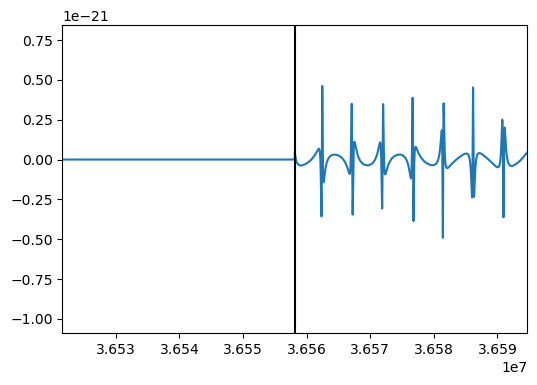

In [87]:
time = np.arange(len(emri_test)) * dt

fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(time, emri_test.real.get())
ax.axvline(emri_waveform.initial_zeros_length*dt, color='black')

ax.set_xlim([0.999* emri_waveform.initial_zeros_length*dt, 1.001*emri_waveform.initial_zeros_length*dt])

In [61]:
2* ASTRONOMICAL_YEAR / dt

25246519.810836475

In [62]:
emri_waveform.initial_zeros_length

14623261

### Response comparison

In [64]:
!nvidia-smi

Mon Mar  2 22:37:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:17:00.0 Off |                    0 |
| N/A   40C    P0             67W /  300W |    9547MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [67]:
# create orbits module

esa = Orbits(filename=orbit_file, 
            use_gpu=use_gpu, 
            force_backend=force_backend, 
            linear_interp_setup=False)

In [68]:
T = Time + 2 *  emri_waveform.initial_zeros_length *dt /ASTRONOMICAL_YEAR

In [93]:
emri_params = [M, mu, a * np.sign(np.cos(inclination)), p0, e0, 1.0, dist,
               qS_ecl, phiS_ecl, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, ra, dec]
index_lambda=14
index_beta=15

In [94]:
# Pass sky position as two extra parameters in ra, dec and pop them from list when passing params to FEW
emri_TDI_list = ResponseWrapper(
    emri_waveform,
    T,
    dt,
    index_lambda,
    index_beta,
    t0=t0,
    flip_hx=True,  # set to True if waveform is h+ - ihx
    force_backend=force_backend,
    remove_sky_coords=True,  # True if the waveform generator does not take sky coordinates
    is_ecliptic_latitude=False,  # False if using polar angle (theta)
    remove_garbage=False,  # removes the beginning of the signal that has bad information
    orbits=esa,
    **tdi_kwargs,
)

In [95]:
def emri_TDI(*params):
    start_flr = emri_waveform.initial_zeros_length
    return cp.asarray(emri_TDI_list(*params))[:, start_flr:-start_flr]

In [96]:
len(emri_params)

16

In [97]:
chans = emri_TDI(*emri_params)

In [98]:
time = np.arange(len(chans[0])) * dt / YRSID_SI

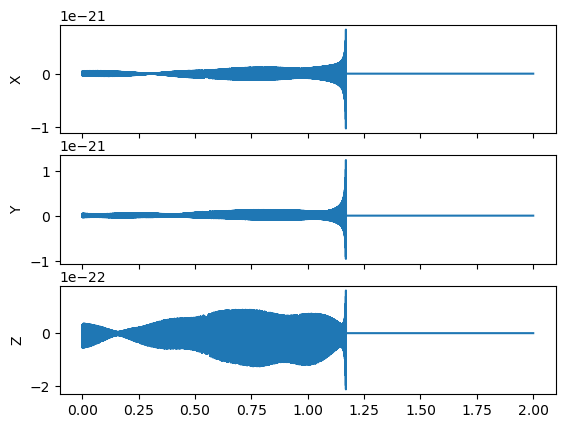

In [99]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i, lab in enumerate(["X", "Y", "Z"]):
    ax[i].plot(time[::10], chans[i].get()[::10])
    # ax[i].set_xlim([1.999, 2.001])
    ax[i].set_ylabel(lab)

#### Inspect TDI channels: source 6

In [100]:
time_sim_L1 = np.arange(t0_l0+322.5, x2.shape[0]*delta_t + t0_l0+322.5, dt)[:-1] / YRSID_SI 
time_flr_L1 = np.arange(t0_orbits + emri_waveform.initial_zeros_length*dt, chans.shape[1]*delta_t + t0_orbits + emri_waveform.initial_zeros_length*dt - dt, dt) /YRSID_SI

In [101]:
time_sim_L1.shape

(25246480,)

In [102]:
time_flr_L1.shape

(25248920,)

In [103]:
(25248921 - 25246480)* 2.5

6102.5

In [104]:
emri_waveform.initial_zeros_length

14623261

Text(0.5, 1.0, 'TDI X channel')

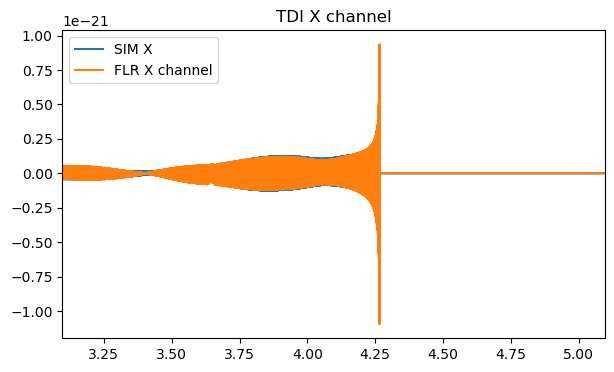

In [105]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.plot(time_sim_L1, x2, label='SIM X')   
ax.plot(time_flr_L1, chans[0].get(), label='FLR X channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI X channel')

Text(0.5, 1.0, 'TDI Y channel')

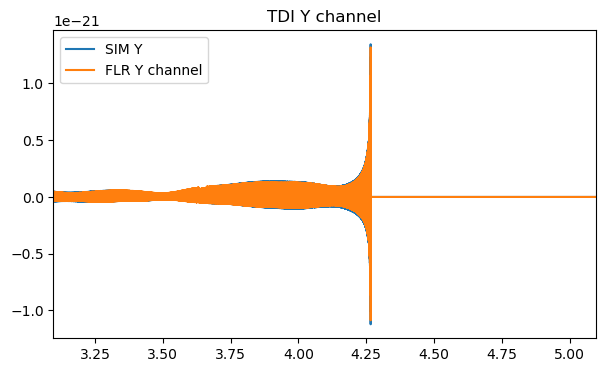

In [106]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.plot(time_sim_L1, y2, label='SIM Y')   
ax.plot(time_flr_L1, chans[1].get(), label='FLR Y channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI Y channel')

Text(0.5, 1.0, 'TDI Z channel')

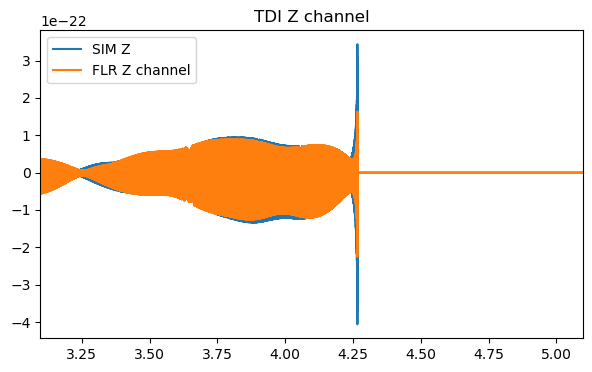

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.plot(time_sim_L1, z2, label='SIM Z')   
ax.plot(time_flr_L1, chans[2].get(), label='FLR Z channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI Z channel')

In [62]:
time_flr_L1

array([3.0968036 , 3.09680368, 3.09680376, ..., 5.0969935 , 5.09699358,
       5.09699366], shape=(25248920,))

In [63]:
time_sim_L1

array([3.09683118, 3.09683126, 3.09683134, ..., 5.09682779, 5.09682787,
       5.09682795], shape=(25246480,))

In [64]:
25248920 - 25246480

2440

In [65]:
(3.09683118 - 3.0968036)*ASTRONOMICAL_YEAR / dt

348.1495081945791

Text(0.5, 1.0, 'TDI X channel')

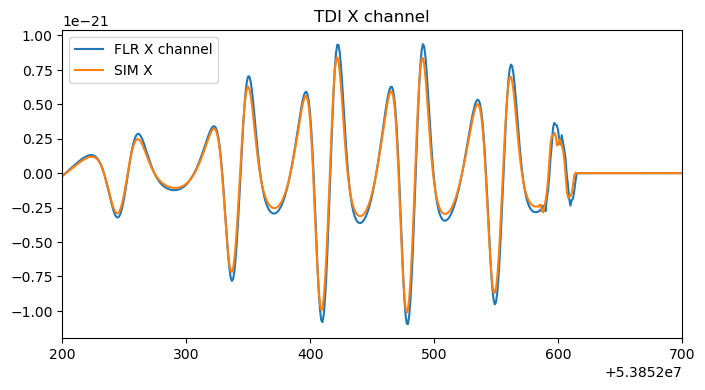

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))


ax.plot(time_flr_L1*YRSID_SI/dt, chans[0].get(), label='FLR X channel')
ax.plot(time_sim_L1*YRSID_SI/dt, x2, label='SIM X')   
ax.set_xlim([5.38522e7,5.38527e7 ])
ax.legend(loc='upper left')
ax.set_title('TDI X channel')

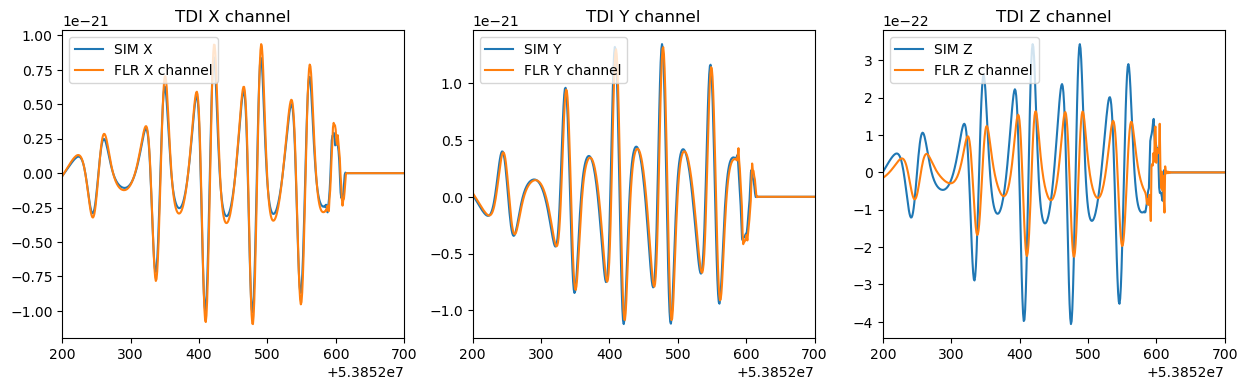

In [67]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labels = ['X', 'Y', 'Z']
sim_data = {0: x2, 1: y2, 2: z2}

for i, lab in enumerate(labels):
    ax[i].plot(time_sim_L1*YRSID_SI/dt, sim_data[i], label=f'SIM {lab}')   
    ax[i].plot(time_flr_L1*YRSID_SI/dt, chans[i].get(), label=f'FLR {lab} channel')
    ax[i].set_xlim([5.38522e7,5.38527e7 ])
    ax[i].legend(loc='upper left')
    
    ax[i].set_title(f'TDI {lab} channel')

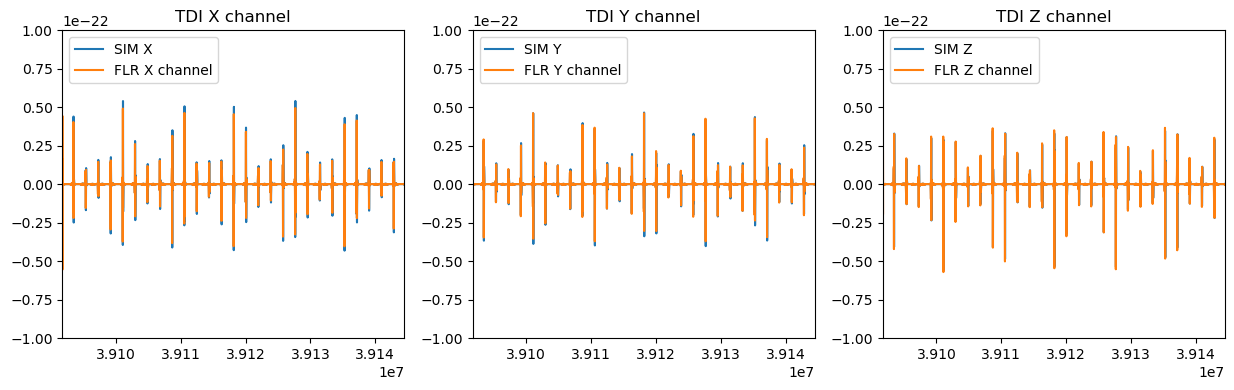

In [72]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labels = ['X', 'Y', 'Z']
sim_data = {0: x2, 1: y2, 2: z2}

for i, lab in enumerate(labels):
    ax[i].plot(time_sim_L1*YRSID_SI/dt, sim_data[i], label=f'SIM {lab}')   
    ax[i].plot(time_flr_L1*YRSID_SI/dt, chans[i].get(), label=f'FLR {lab} channel')
    ax[i].set_xlim([3.0968036 * YRSID_SI/dt, 3.0968036 * YRSID_SI/dt + 0.00527e7 ])
    ax[i].set_ylim([-1e-22, 1e-22])
    ax[i].legend(loc='upper left')
    
    ax[i].set_title(f'TDI {lab} channel')

In [85]:
print(len(sim_data[0]))
print(len(chans[i].get()))
min_len = min(len(sim_data[0]), len(chans[0].get()))

25246480
25248920


In [81]:
# window and fft signals
wd_tdi = cp.asarray(tukey(min_len, alpha=0.01))
flr_sliced = chans[:, :min_len]
X_sim_fft = cp.fft.rfft(cp.asarray(x2) * wd_tdi)[1:]
X_flr_fft = cp.fft.rfft(flr_sliced[0] * wd_tdi)[1:]

freq_L1 = cp.fft.rfftfreq(len(wd_tdi), dt)

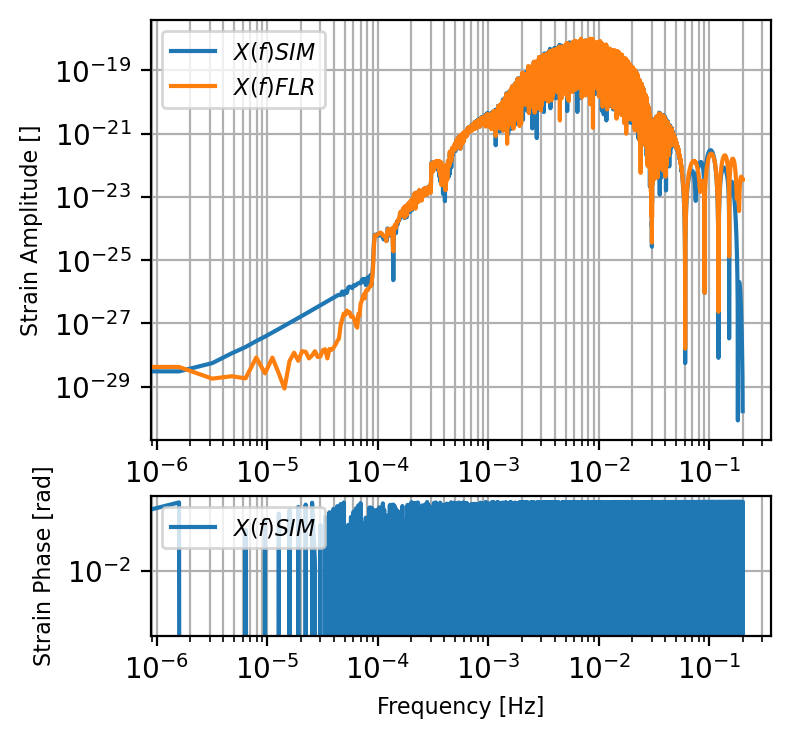

In [82]:
# Comparison in frequency domain
FontSize = 8
DecimFactor = 100
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(4,4), dpi=200, gridspec_kw={'height_ratios': [3, 1]})
axs[0].loglog(freq_L1[::DecimFactor].get(), np.abs(X_sim_fft[::DecimFactor].get()), label='$X(f) SIM$')
axs[0].loglog(freq_L1[::DecimFactor].get(), np.abs(X_flr_fft[::DecimFactor].get()), label='$X(f) FLR$')
# axs[0].loglog(freq_L1[::DecimFactor].get(), np.abs(residual[::DecimFactor].get()), label='$X(f) residual$')
axs[0].legend(fontsize=FontSize, loc='upper left')
axs[0].grid(visible=True, which='both')
axs[0].set_xlabel('Frequency [Hz]', fontsize=FontSize);
axs[0].set_ylabel('Strain Amplitude []', fontsize=FontSize);

# axs[0].set_xlim([fmin, fmax]);
# axs[0].set_ylim([0.1*np.min(np.abs(T_fft[freq_L1 >= fmin])),
#                  10*np.max(np.abs(A_fft[freq_L1 <= fmax]))]);

axs[1].loglog(freq_L1[::DecimFactor].get(), np.angle(X_sim_fft[::DecimFactor].get()), label='$X(f) SIM$')
# axs[1].loglog(freq_L1[::DecimFactor].get(), np.angle(X_flr_fft[::DecimFactor].get()), label='$X(f) FLR$')
# axs[1].loglog(freq_L1[::DecimFactor], np.angle(T_fft[::DecimFactor]), label='$T(f)$')

axs[1].legend(fontsize=FontSize, loc='upper left')
axs[1].grid(visible=True, which='both')

axs[1].set_xlabel('Frequency [Hz]', fontsize=FontSize);
axs[1].set_ylabel('Strain Phase [rad]', fontsize=FontSize);

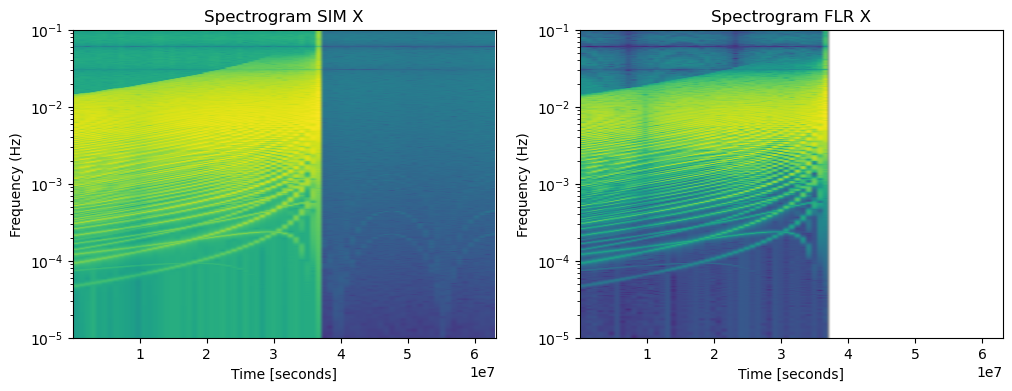

In [84]:
# Make spectrograms
fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].set_title('Spectrogram SIM X')
Pxx, freqs, bins, im = ax[0].specgram(x2, 
                                    NFFT=time_sim_L1.size//75, 
                                    Fs=1/dt)
ax[1].set_title('Spectrogram FLR X')
Pxx, freqs, bins, im = ax[1].specgram(flr_sliced[0].get(), 
                                    NFFT=time_sim_L1.size//75, 
                                    Fs=1/dt)

'''
The `specgram` method returns 4 objects. They are:
   - Pxx: the periodogram
   - freqs: the frequency vector
   - bins: the centers of the time bins
   - im: the .image.AxesImage instance representing the data in the plot
'''


for i in range(2):
    ax[i].set_yscale('log')
    ax[i].set_ylim(1e-5, 1e-1)
    ax[i].set_xlabel('Time [seconds]')
    ax[i].set_ylabel('Frequency (Hz)')

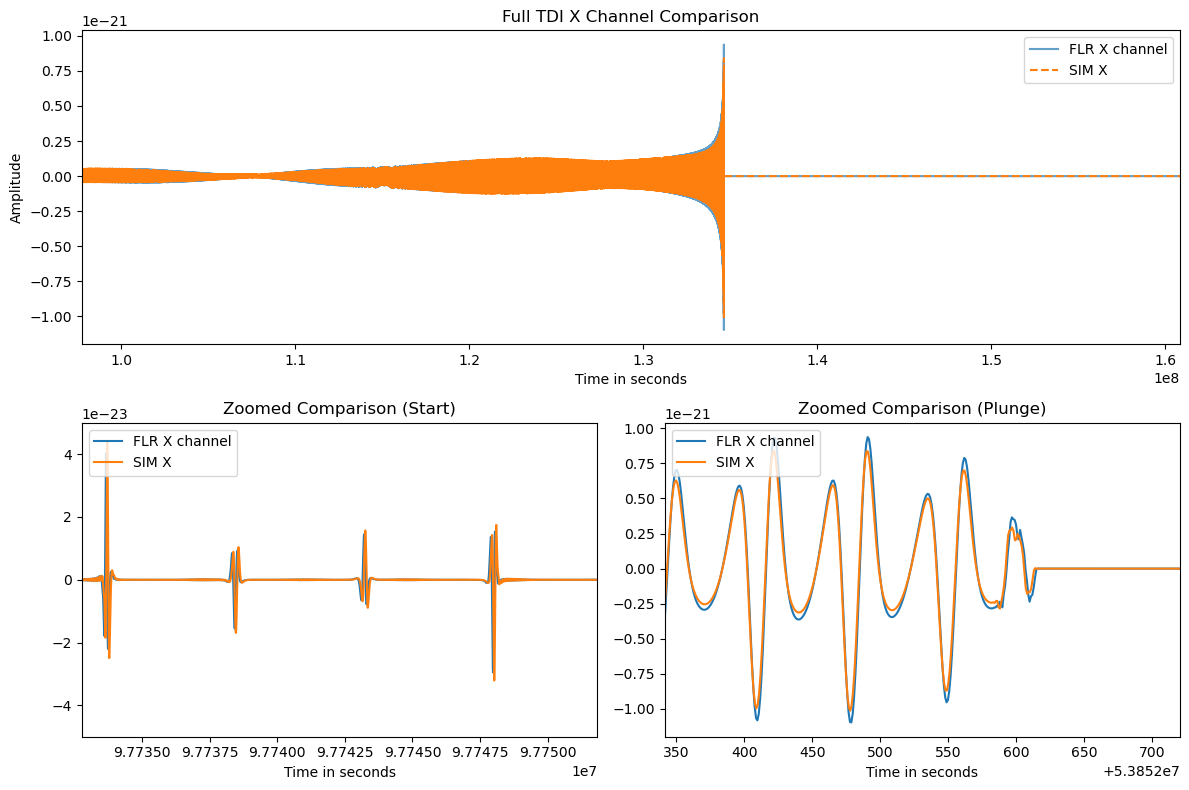

In [86]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2)

# panel with full thing
ax_top = fig.add_subplot(gs[0, :]) # Spans row 0, all columns
ax_top.plot(time_flr_L1*YRSID_SI, chans[0].get(), label='FLR X channel', alpha=0.7)
ax_top.plot(time_sim_L1*YRSID_SI, x2, label='SIM X', linestyle='--')
ax_top.set_xlim([time_sim_L1[0]*YRSID_SI, time_sim_L1[-1]*YRSID_SI])
ax_top.set_title('Full TDI X Channel Comparison')
ax_top.legend(loc='upper right')
ax_top.set_xlabel('Time in seconds')
ax_top.set_ylabel('Amplitude')

# bottom left
ax_left = fig.add_subplot(gs[1, 0])
ax_left.plot(time_flr_L1*YRSID_SI, chans[0].get(), label='FLR X channel')
ax_left.plot(time_sim_L1*YRSID_SI, x2, label='SIM X')   
ax_left.set_xlim([(time_sim_L1[0])*YRSID_SI+1000*dt, (time_sim_L1[0]+ 0.00005)*YRSID_SI+8000*dt])
ax_left.set_ylim([-5e-23, 5e-23])
ax_left.legend(loc='upper left')
ax_left.set_xlabel('Time in seconds')
ax_left.set_title('Zoomed Comparison (Start)')

# Bottom right
ax_right = fig.add_subplot(gs[1, 1])
ax_right.plot(time_flr_L1*YRSID_SI/dt, chans[0].get(), label='FLR X channel')
ax_right.plot(time_sim_L1*YRSID_SI/dt, x2, label='SIM X')   
ax_right.set_xlim([(4.26612)*YRSID_SI/dt, (4.26615)*YRSID_SI/dt])
ax_right.legend(loc='upper left')
ax_right.set_xlabel('Time in seconds')
ax_right.set_title('Zoomed Comparison (Plunge)')

plt.tight_layout()
plt.show()